In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


file_path ='/Users/yildizaydin/Desktop/VeriSetleri.csv/dataset.csv'

try:
    df = pd.read_csv(file_path)
    print("Veri seti başarıyla yüklendi.")
    print(f"Toplam {df.shape[0]} satır ve {df.shape[1]} sütun bulunmaktadır.")
    print("\nVerinin İlk 5 Satırı:")
    print(df.head())
except FileNotFoundError:
    print(f"HATA: '{file_path}' adında bir dosya bulunamadı.")
  
except Exception as e:
    # Diğer olası hataları yakalamak için
    print(f"Bilinmeyen bir hata oluştu: {e}")

Veri seti başarıyla yüklendi.
Toplam 78792 satır ve 21 sütun bulunmaktadır.

Verinin İlk 5 Satırı:
   Year LocationAbbr      LocationDesc GeographicLevel DataSource  \
0  2020           AK            Denali          County       NVSS   
1  2020           CA        California           State       NVSS   
2  2020           CO       Park County          County       NVSS   
3  2020           FL     Walton County          County       NVSS   
4  2020           GA  Whitfield County          County       NVSS   

                     Class                    Topic  Data_Value  \
0  Cardiovascular Diseases  Heart Disease Mortality       348.8   
1  Cardiovascular Diseases  Heart Disease Mortality       230.1   
2  Cardiovascular Diseases  Heart Disease Mortality       135.9   
3  Cardiovascular Diseases  Heart Disease Mortality       126.5   
4  Cardiovascular Diseases  Heart Disease Mortality       155.1   

          Data_Value_Unit                                    Data_Value_Type  \
0  

In [4]:

all_cols = df.columns.tolist()

geo_level_col = None
for col in all_cols:
    if col == 'GeographicLevel':
        geo_level_col = col
        break
    if col.strip() == 'GeographicLevel':
        geo_level_col = col 
        break

if geo_level_col is None:
    print("HATA: 'GeographicLevel' adında veya buna benzeyen bir sütun bulunamadı.")
    print("Mevcut Sütunlar:", all_cols)
   
    raise KeyError("'GeographicLevel' sütunu veri setinde mevcut değil.")


df_clean = df[df[geo_level_col] == 'County'].copy()
print(f"Sadece ilçe  verisi seçildi. Satır sayısı: {df_clean.shape[0]}")


cols_to_drop = [
    'Year', 'DataSource', 'Class', 'Topic', geo_level_col, 
    'Data_Value_Type', 'Data_Value_Unit', 'Data_Value_Footnote_Symbol',
    'Data_Value_Footnote', 'StratificationCategory1', 'StratificationCategory2',
    'TopicID', 'ClassID', 'TopicType',
    'LocationDesc' 
]

existing_cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_cols_to_drop, errors='ignore')


rename_mapping = {
    'LocationAbbr': 'State',
    'LocationID': 'FIPS',           
    'Data_Value': 'Mortality_Rate',
    'Stratification1': 'Gender',
    'Stratification2': 'Race_Ethnicity'
}

valid_rename_mapping = {
    old_name: new_name for old_name, new_name in rename_mapping.items() 
    if old_name in df_clean.columns
}

df_clean = df_clean.rename(columns=valid_rename_mapping)

print("yeniden adlandırılan sütünlar")

df_clean.head()

Sadece ilçe  verisi seçildi. Satır sayısı: 77424
yeniden adlandırılan sütünlar


,State,Mortality_Rate,Gender,Race_Ethnicity,FIPS,Y_lat,X_lon,Georeference
0,AK,348.8,Male,White,2068,63.678820,-149.960801,POINT (-149.9608012 63.67881971)
2,CO,135.9,Female,White,8093,39.115616,-105.708698,POINT (-105.7086982 39.11561621)
3,FL,126.5,Female,Asian,12131,30.655966,-86.157457,POINT (-86.15745736 30.65596581)
4,GA,155.1,Female,Hispanic,13313,34.803854,-84.962112,POINT (-84.96211184 34.80385386)
5,GA,NaN,Female,Asian,13299,31.051889,-82.420394,POINT (-82.4203935 31.05188914)


In [5]:

df_clean = df[df[geo_level_col] == 'County'].copy()
print(f"\n1. Adım: Sadece ilçe verisi seçildi. Yeni satır sayısı: {df_clean.shape[0]}")

cols_to_drop = [
    'Year', 'DataSource', 'Class', 'Topic', geo_level_col,
    'Data_Value_Type', 'Data_Value_Unit', 'Data_Value_Footnote_Symbol',
    'Data_Value_Footnote', 'StratificationCategory1', 'StratificationCategory2',
    'TopicID', 'ClassID', 'TopicType', 'LocationDesc' 
]

existing_cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_cols_to_drop, errors='ignore')
print("2. Adım: Gereksiz sütunlar atıldı.")

rename_mapping = {
    'LocationAbbr': 'State',
    'LocationID': 'FIPS',            
    'Data_Value': 'Mortality_Rate',
    'Stratification1': 'Gender',
    'Stratification2': 'Race_Ethnicity'
}

valid_rename_mapping = {
    old_name: new_name for old_name, new_name in rename_mapping.items() 
    if old_name in df_clean.columns
}

df_clean = df_clean.rename(columns=valid_rename_mapping)
print("3. Adım: Sütunlar yeniden adlandırıldı.")



print("\nEksik Veri Kontrolü:")
print(df_clean.isnull().sum())

initial_rows = df_clean.shape[0]
df_clean.dropna(subset=['Mortality_Rate'], inplace=True)
print(f"\n4. Adım: 'Mortality_Rate' sütununda eksik olan {initial_rows - df_clean.shape[0]} satır silindi. Yeni satır sayısı: {df_clean.shape[0]}")

print("\nVeri Tipi Kontrolü:")
df_clean.info()

if 'Mortality_Rate' in df_clean.columns and df_clean['Mortality_Rate'].dtype == 'object':
   
    df_clean['Mortality_Rate'] = pd.to_numeric(df_clean['Mortality_Rate'], errors='coerce') 
    df_clean.dropna(subset=['Mortality_Rate'], inplace=True)
    print("5. Adım: 'Mortality_Rate' sayıya çevrildi ve dönüştürülemeyen satırlar silindi.")

df_clean.head()


1. Adım: Sadece ilçe verisi seçildi. Yeni satır sayısı: 77424
2. Adım: Gereksiz sütunlar atıldı.
3. Adım: Sütunlar yeniden adlandırıldı.

Eksik Veri Kontrolü:
State                 0
Mortality_Rate    43993
Gender                0
Race_Ethnicity        0
FIPS                  0
Y_lat                 0
X_lon                 0
Georeference          0
dtype: int64

4. Adım: 'Mortality_Rate' sütununda eksik olan 43993 satır silindi. Yeni satır sayısı: 33431

Veri Tipi Kontrolü:
<class 'pandas.core.frame.DataFrame'>
Index: 33431 entries, 0 to 78790
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           33431 non-null  object 
 1   Mortality_Rate  33431 non-null  float64
 2   Gender          33431 non-null  object 
 3   Race_Ethnicity  33431 non-null  object 
 4   FIPS            33431 non-null  int64  
 5   Y_lat           33431 non-null  float64
 6   X_lon           33431 non-null  float64
 7   Georefe

,State,Mortality_Rate,Gender,Race_Ethnicity,FIPS,Y_lat,X_lon,Georeference
0,AK,348.8,Male,White,2068,63.678820,-149.960801,POINT (-149.9608012 63.67881971)
2,CO,135.9,Female,White,8093,39.115616,-105.708698,POINT (-105.7086982 39.11561621)
3,FL,126.5,Female,Asian,12131,30.655966,-86.157457,POINT (-86.15745736 30.65596581)
4,GA,155.1,Female,Hispanic,13313,34.803854,-84.962112,POINT (-84.96211184 34.80385386)
6,IA,168.0,Overall,Hispanic,19093,42.387689,-95.523143,POINT (-95.52314316 42.38768939)


In [6]:
df_clean['FIPS'] = df_clean['FIPS'].astype(str)

df_clean['FIPS'] = df_clean['FIPS'].str.zfill(5)

print(df_clean[['State', 'FIPS', 'Gender', 'Race_Ethnicity']].head())

  State   FIPS   Gender Race_Ethnicity
0    AK  02068     Male          White
2    CO  08093   Female          White
3    FL  12131   Female          Asian
4    GA  13313   Female       Hispanic
6    IA  19093  Overall       Hispanic


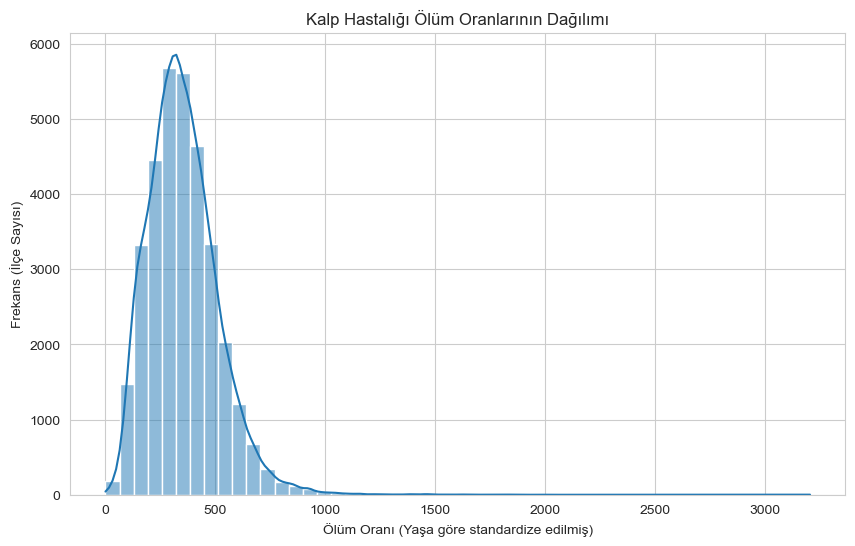

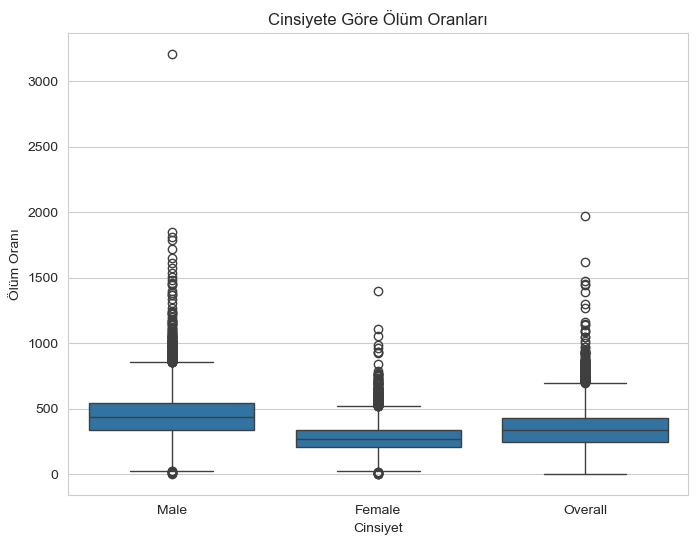

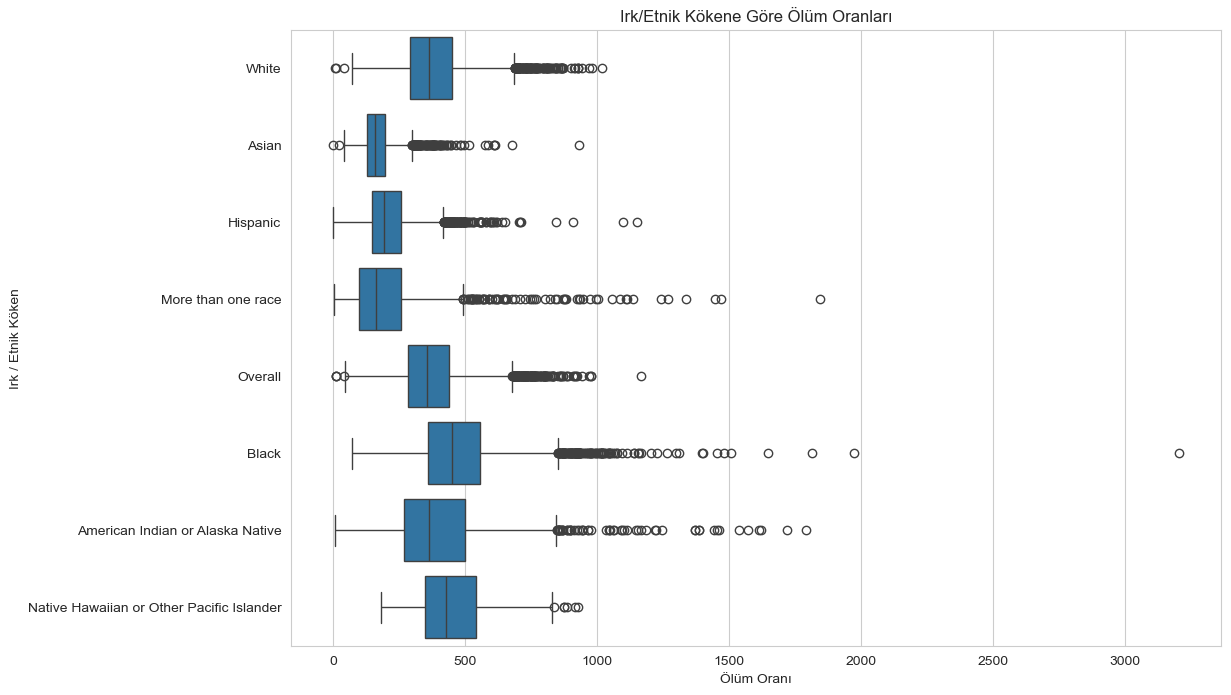

In [8]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df_clean['Mortality_Rate'], kde=True, bins=50)
plt.title('Kalp Hastalığı Ölüm Oranlarının Dağılımı')
plt.xlabel('Ölüm Oranı (Yaşa göre standardize edilmiş)')
plt.ylabel('Frekans (İlçe Sayısı)')
plt.show()

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='Gender', y='Mortality_Rate')
plt.title('Cinsiyete Göre Ölüm Oranları')
plt.xlabel('Cinsiyet')
plt.ylabel('Ölüm Oranı')
plt.show()

plt.figure(figsize=(12, 8))
sns.boxplot(data=df_clean, y='Race_Ethnicity', x='Mortality_Rate', orient='h')
plt.title('Irk/Etnik Kökene Göre Ölüm Oranları')
plt.xlabel('Ölüm Oranı')
plt.ylabel('Irk / Etnik Köken')
plt.show()

In [9]:
import pandas as pd
import sys

try:
    import openpyxl
except ImportError:
    print("HATA")
    sys.exit()


files_to_check = ["/Users/yildizaydin/Desktop/VeriSetleri.csv/Poverty2023.xlsx","/Users/yildizaydin/Desktop/VeriSetleri.csv/Education2023.xlsx", "/Users/yildizaydin/Desktop/VeriSetleri.csv/Unemployment2023.xlsx"]


for file in files_to_check:
        
    try:
        xls = pd.ExcelFile(file)
        
        sheet_names = xls.sheet_names
        print(f"Bulunan Sekme Adları: {sheet_names}")
        
       
        data_sheet_name = None
        for name in sheet_names:
            if "description" not in name.lower() and "readme" not in name.lower():
                data_sheet_name = name
                print(f"Veri sekmesi olarak '{data_sheet_name}' seçildi.")
                break
        
        if not data_sheet_name:
            print("Veri sekmesi bulunamadı.")
            continue

        print(f"\n'{data_sheet_name}' sekmesinin ilk 10 satırı:")
        df_preview = pd.read_excel(xls, sheet_name=data_sheet_name, header=None, nrows=10)
        print(df_preview)

       
        try:
            header_row_index = 4 
            df_cols = pd.read_excel(xls, sheet_name=data_sheet_name, header=header_row_index)
            print(f"\n'{data_sheet_name}' (Başlık Satırı: {header_row_index}) Sütun Listesi:")
            for col in df_cols.columns:
                print(col)
        except Exception as e:
            print(f"Başlıklar okunurken hata: {e}.")

    except FileNotFoundError:
        print(f"HATA: '{file}' dosyası bulunamadı.")
    except Exception as e:
        print(f"Bir hata oluştu: {e}")

Bulunan Sekme Adları: ['Poverty Data 2023', 'Variable Descriptions']
Veri sekmesi olarak 'Poverty Data 2023' seçildi.

'Poverty Data 2023' sekmesinin ilk 10 satırı:
                                                  0      1               2   \
0  Poverty estimates for United States, States, a...    NaN             NaN   
1  Source: U.S. Department of Commerce, Bureau of...    NaN             NaN   
2  Poverty status is determined at the family lev...    NaN             NaN   
3  This table was prepared by USDA, Economic Rese...    NaN             NaN   
4                                          FIPS_Code  Stabr       Area_Name   
5                                              00000     US   United States   
6                                              01000     AL         Alabama   
7                                              01001     AL  Autauga County   
8                                              01003     AL  Baldwin County   
9                                            

In [10]:
print("\nBölüm 2: Sosyoekonomik veriler yükleniyor...")

try:

    INCOME_DOSYA_ADI = "/Users/yildizaydin/Desktop/VeriSetleri.csv/Unemployment2023.xlsx"
    INCOME_SEKME_ADI = "Unemployment Med HH Income"
    INCOME_BASLIK_SATIRI = 4 #
    
    df_income = pd.read_excel(INCOME_DOSYA_ADI, sheet_name=INCOME_SEKME_ADI, header=INCOME_BASLIK_SATIRI, dtype={'FIPS_Code': str})
    INCOME_SUTUNLARI = {
        'FIPS_Code': 'FIPS',
        'Median_Household_Income_2022': 'Median_Income_2022' 
    }
    df_income = df_income[list(INCOME_SUTUNLARI.keys())].copy()
    df_income.rename(columns=INCOME_SUTUNLARI, inplace=True)
    df_income['FIPS'] = df_income['FIPS'].str.zfill(5)
    print(f"'{INCOME_DOSYA_ADI}' yüklendi ve işlendi.")

   
    EDUCATION_DOSYA_ADI = "/Users/yildizaydin/Desktop/VeriSetleri.csv/Education2023.xlsx"
    EDUCATION_SEKME_ADI = "Education 1970 to 2023"
    EDUCATION_BASLIK_SATIRI = 3
    
    df_edu = pd.read_excel(EDUCATION_DOSYA_ADI, sheet_name=EDUCATION_SEKME_ADI, header=EDUCATION_BASLIK_SATIRI, dtype={'FIPS Code': str})
    EDUCATION_SUTUNLARI = {
        'FIPS Code': 'FIPS', 
        "Percent of adults with a bachelor's degree or higher, 2019-23": 'Edu_Bach_Pct_2019-23'
    }
    df_edu = df_edu[list(EDUCATION_SUTUNLARI.keys())].copy()
    df_edu.rename(columns=EDUCATION_SUTUNLARI, inplace=True)
    df_edu['FIPS'] = df_edu['FIPS'].str.zfill(5)
    print(f"'{EDUCATION_DOSYA_ADI}' yüklendi ve işlendi.")

    
    POVERTY_DOSYA_ADI = "/Users/yildizaydin/Desktop/VeriSetleri.csv/Poverty2023.xlsx"
    POVERTY_SEKME_ADI = "Poverty Data 2023"
    POVERTY_BASLIK_SATIRI = 4 
    
    df_poverty = pd.read_excel(POVERTY_DOSYA_ADI, sheet_name=POVERTY_SEKME_ADI, header=POVERTY_BASLIK_SATIRI, dtype={'FIPS_Code': str})
    POVERTY_SUTUNLARI = {
        'FIPS_Code': 'FIPS',
        'PCTPOVALL_2023': 'Poverty_Pct_2023' 
    }
    df_poverty = df_poverty[list(POVERTY_SUTUNLARI.keys())].copy()
    df_poverty.rename(columns=POVERTY_SUTUNLARI, inplace=True)
    df_poverty['FIPS'] = df_poverty['FIPS'].str.zfill(5)
    print(f"'{POVERTY_DOSYA_ADI}' yüklendi ve işlendi.")

except FileNotFoundError as e:
    print(f"HATA: Dosya bulunamadı -> {e}.")
    raise SystemExit("Script durduruldu.")
except KeyError as e:
    print(f"HATA: Sütun adı bulunamadı -> {e}.")
    print("Bir sütun adında yazım hatası olabilir, lütfen kodu kontrol edin.")
    raise SystemExit("Script durduruldu.")
except Exception as e:
    print(f"Genel bir hata oluştu: {e}")
    raise SystemExit("Script durduruldu.")


print("\nBölüm 3: Tüm veriler birleştiriliyor...")

df_socio_merged = pd.merge(df_income, df_edu, on='FIPS', how='outer')
df_socio_merged = pd.merge(df_socio_merged, df_poverty, on='FIPS', how='outer')

df_final_merged = pd.merge(df_clean, df_socio_merged, on='FIPS', how='left')

print("Birleştirme tamamlandı.")

print(f"Birleştirmeden önce satır sayısı: {df_clean.shape[0]}")
print(f"Birleştirmeden sonra satır sayısı: {df_final_merged.shape[0]}")

original_rows = df_final_merged.shape[0]
df_final_merged.dropna(inplace=True) 
final_rows = df_final_merged.shape[0]

print(f"Sosyoekonomik verisi eksik olan {original_rows - final_rows} satır silindi.")
print(f"Veri setinin son boyutu: {df_final_merged.shape}")


Bölüm 2: Sosyoekonomik veriler yükleniyor...
'/Users/yildizaydin/Desktop/VeriSetleri.csv/Unemployment2023.xlsx' yüklendi ve işlendi.
'/Users/yildizaydin/Desktop/VeriSetleri.csv/Education2023.xlsx' yüklendi ve işlendi.
'/Users/yildizaydin/Desktop/VeriSetleri.csv/Poverty2023.xlsx' yüklendi ve işlendi.

Bölüm 3: Tüm veriler birleştiriliyor...
Birleştirme tamamlandı.
Birleştirmeden önce satır sayısı: 33431
Birleştirmeden sonra satır sayısı: 33431
Sosyoekonomik verisi eksik olan 401 satır silindi.
Veri setinin son boyutu: (33030, 11)


In [12]:

# FAZ 2 İÇİN FİNAL VERİ SETİNİ KAYDETME
output_file = "tum_veriler_temiz_birlesmis.csv"
df_final_merged.to_csv(output_file, index=False)

print(f"\n--- FAZ 1 TAMAMLANDI ---")
print(f"Tüm temizlenmiş ve birleştirilmiş veriler '{output_file}' olarak kaydedildi.")
print(f"Tüm grup üyeleri bireysel çalışma için bu '{output_file}' dosyasını kullanabilir.")


--- FAZ 1 TAMAMLANDI ---
Tüm temizlenmiş ve birleştirilmiş veriler 'tum_veriler_temiz_birlesmis.csv' olarak kaydedildi.
Tüm grup üyeleri bireysel çalışma için bu 'tum_veriler_temiz_birlesmis.csv' dosyasını kullanabilir.


In [25]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

print("\n--- FAZ 2 BAŞLANGIÇ: Üye 2 (Sarmalayıcı Yöntemler) ---")

median_rate = df_final_merged['Mortality_Rate'].median()
df_final_merged['Mortality_Class'] = df_final_merged['Mortality_Rate'].apply(
    lambda x: 1 if x > median_rate else 0  
)

print(f"Ölüm Oranı Medyanı: {median_rate:.2f}")
print("Yeni Sınıf Dağılımı:")
print(df_final_merged['Mortality_Class'].value_counts())

features_to_drop = ['Mortality_Rate', 'FIPS', 'Georeference', 'State'] 
X = df_final_merged.drop(columns=features_to_drop + ['Mortality_Class'])
y = df_final_merged['Mortality_Class']


--- FAZ 2 BAŞLANGIÇ: Üye 2 (Sarmalayıcı Yöntemler) ---
Ölüm Oranı Medyanı: 339.30
Yeni Sınıf Dağılımı:
Mortality_Class
0    16516
1    16514
Name: count, dtype: int64


In [26]:

categorical_features = ['Gender', 'Race_Ethnicity']
numerical_features = X.columns.drop(categorical_features).tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

feature_names = numerical_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))

print("\nVeri Ön İşleme (StandardScaler ve OneHotEncoder) tamamlandı.")
print(f"Toplam Özellik Sayısı: {len(feature_names)}")


Veri Ön İşleme (StandardScaler ve OneHotEncoder) tamamlandı.
Toplam Özellik Sayısı: 16


In [30]:
print("\n DENEY 1: RFE ve GridSearchCV Hazırlığı")

# --- RFE ile Özellik Seçimi (Sarmalayıcı Yöntemler) ---
# Görev: RFE ile 12 özellik seçimi
estimator = DecisionTreeClassifier(random_state=42)
rfe = RFE(estimator, n_features_to_select=12, step=1)
rfe.fit(X_train, y_train)

selected_mask = rfe.support_
selected_features_rfe = [name for name, is_selected in zip(feature_names, selected_mask) if is_selected]

print(f"\n RFE ile Seçilen 12 Özellik:\n{selected_features_rfe}")

X_train_rfe = X_train[:, selected_mask]
X_test_rfe = X_test[:, selected_mask]


#  GridSearchCV  
#  k-NN için GridSearchCV kullanmak
print("\n3.1: k-NN (n_neighbors) için GridSearchCV Uygulanıyor...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) 
param_grid = {'n_neighbors': [3, 5, 7, 9, 11]} 
knn = KNeighborsClassifier()

# F1-Score metriğini optimize 
grid_search = GridSearchCV(knn, param_grid, cv=cv, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_rfe, y_train)

best_k = grid_search.best_params_['n_neighbors']
print(f" En İyi k (n_neighbors) Değeri (GridSearchCV): {best_k}")


#  5-FOLD CROSS VALIDATION 
dt_cv_score = cross_val_score(DecisionTreeClassifier(random_state=42), X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()
print(f"\nDecision Tree (Tüm Özellikler) 5-Fold CV Accuracy: {dt_cv_score:.4f}")

knn_cv_score = cross_val_score(KNeighborsClassifier(n_neighbors=best_k), X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1).mean()
print(f"k-NN (Tüm Özellikler) 5-Fold CV Accuracy: {knn_cv_score:.4f}")


 DENEY 1: RFE ve GridSearchCV Hazırlığı

 RFE ile Seçilen 12 Özellik:
['Y_lat', 'X_lon', 'Median_Income_2022', 'Edu_Bach_Pct_2019-23', 'Poverty_Pct_2023', 'Gender_Female', 'Gender_Overall', 'Race_Ethnicity_Asian', 'Race_Ethnicity_Black', 'Race_Ethnicity_Hispanic', 'Race_Ethnicity_More than one race', 'Race_Ethnicity_White']

3.1: k-NN (n_neighbors) için GridSearchCV Uygulanıyor...
 En İyi k (n_neighbors) Değeri (GridSearchCV): 11

Decision Tree (Tüm Özellikler) 5-Fold CV Accuracy: 0.8680
k-NN (Tüm Özellikler) 5-Fold CV Accuracy: 0.8681


In [31]:
print("\n--- DENEY 2: Sarmalayıcı Yöntem (RFE) ile Özellik Seçimi ---")

estimator = DecisionTreeClassifier(random_state=42)

rfe = RFE(estimator, n_features_to_select=12, step=1)
rfe.fit(X_train, y_train)

selected_mask = rfe.support_
selected_features_rfe = [name for name, is_selected in zip(feature_names, selected_mask) if is_selected]

print(f" RFE ile Seçilen 12 Özellik:\n{selected_features_rfe}")

X_train_rfe = X_train[:, selected_mask]
X_test_rfe = X_test[:, selected_mask]


--- DENEY 2: Sarmalayıcı Yöntem (RFE) ile Özellik Seçimi ---
 RFE ile Seçilen 12 Özellik:
['Y_lat', 'X_lon', 'Median_Income_2022', 'Edu_Bach_Pct_2019-23', 'Poverty_Pct_2023', 'Gender_Female', 'Gender_Overall', 'Race_Ethnicity_Asian', 'Race_Ethnicity_Black', 'Race_Ethnicity_Hispanic', 'Race_Ethnicity_More than one race', 'Race_Ethnicity_White']



--- DENEY 3: RFE Özellikleriyle Final Metrikleri ve Hata Analizi ---

--- Decision Tree (RFE) Final Metrikleri ---
Accuracy: 0.8623
F1-Score: 0.8611
ROC AUC: 0.8660
Classification Raporu:
              precision    recall  f1-score   support

           0       0.86      0.87      0.86      4955
           1       0.87      0.85      0.86      4954

    accuracy                           0.86      9909
   macro avg       0.86      0.86      0.86      9909
weighted avg       0.86      0.86      0.86      9909


--- k-NN (RFE + GridSearchCV) Final Metrikleri ---
Accuracy: 0.8582
F1-Score: 0.8591
ROC AUC: 0.9326
Classification Raporu:
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      4955
           1       0.85      0.86      0.86      4954

    accuracy                           0.86      9909
   macro avg       0.86      0.86      0.86      9909
weighted avg       0.86      0.86      0.86      9909



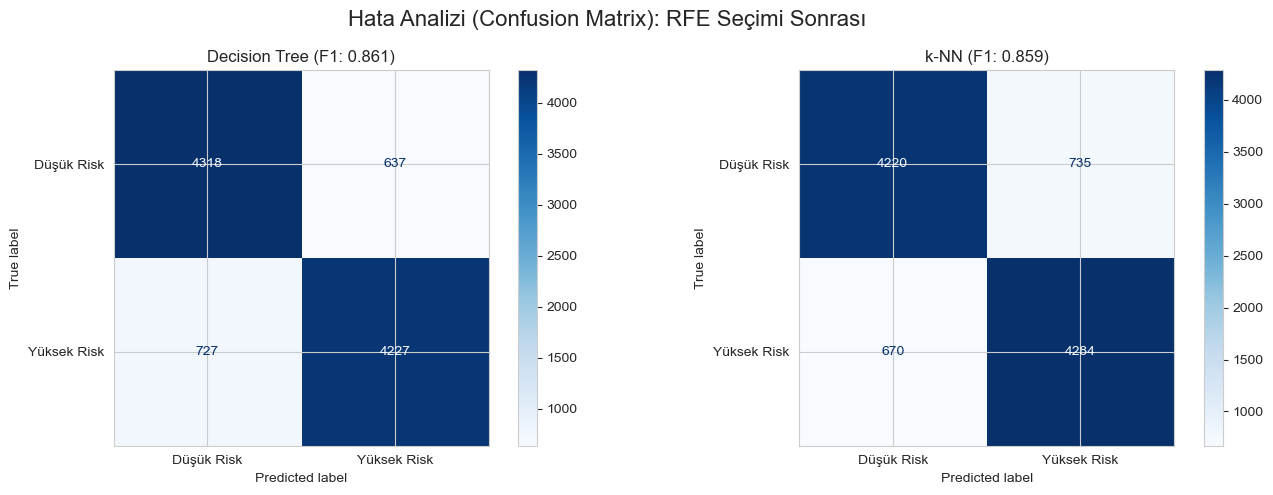


Bireysel çalışma tamamlandı. Tüm zorunlu metrikler hesaplandı.


In [34]:
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import pandas as pd


print("\n--- DENEY 3: RFE Özellikleriyle Final Metrikleri ve Hata Analizi ---")

if 'best_k' not in locals():
    print("UYARI: best_k bulunamadı, varsayılan k=5 kullanılıyor.")
    best_k = 5


# --- MODEL 1: Decision Tree (RFE Özellikleri) ---
dt_final = DecisionTreeClassifier(random_state=42)
dt_final.fit(X_train_rfe, y_train)
y_pred_dt_rfe = dt_final.predict(X_test_rfe)
y_proba_dt_rfe = dt_final.predict_proba(X_test_rfe)[:, 1] 

acc_dt_rfe = accuracy_score(y_test, y_pred_dt_rfe)
f1_dt_final = f1_score(y_test, y_pred_dt_rfe) 
roc_dt_final = roc_auc_score(y_test, y_proba_dt_rfe) 

print("\n--- Decision Tree (RFE) Final Metrikleri ---")
print(f"Accuracy: {acc_dt_rfe:.4f}")
print(f"F1-Score: {f1_dt_final:.4f}") 
print(f"ROC AUC: {roc_dt_final:.4f}")
print("Classification Raporu:")
print(classification_report(y_test, y_pred_dt_rfe))


# --- MODEL 2: k-NN (Optimizasyonlu RFE Özellikleri) ---
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_rfe, y_train)
y_pred_knn_rfe = knn_final.predict(X_test_rfe)
y_proba_knn_rfe = knn_final.predict_proba(X_test_rfe)[:, 1]

acc_knn_rfe = accuracy_score(y_test, y_pred_knn_rfe)
f1_knn_final = f1_score(y_test, y_pred_knn_rfe) 
roc_knn_rfe = roc_auc_score(y_test, y_proba_knn_rfe) 

print("\n--- k-NN (RFE + GridSearchCV) Final Metrikleri ---")
print(f"Accuracy: {acc_knn_rfe:.4f}")
print(f"F1-Score: {f1_knn_final:.4f}") 
print(f"ROC AUC: {roc_knn_rfe:.4f}")
print("Classification Raporu:")
print(classification_report(y_test, y_pred_knn_rfe))

# --- Confusion Matrix (Hata Analizi) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hata Analizi (Confusion Matrix): RFE Seçimi Sonrası', fontsize=16)

# Model 1: Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt_rfe)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Düşük Risk', 'Yüksek Risk'])
disp_dt.plot(ax=axes[0], cmap=plt.cm.Blues, values_format='d')
axes[0].set_title(f'Decision Tree (F1: {f1_dt_final:.3f})') 


# Model 2: k-NN
cm_knn = confusion_matrix(y_test, y_pred_knn_rfe)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Düşük Risk', 'Yüksek Risk'])
disp_knn.plot(ax=axes[1], cmap=plt.cm.Blues, values_format='d')
axes[1].set_title(f'k-NN (F1: {f1_knn_final:.3f})') 


plt.tight_layout()
plt.savefig('uye2_confusion_matrix_final.png')
plt.show()

print("\nBireysel çalışma tamamlandı. Tüm zorunlu metrikler hesaplandı.")

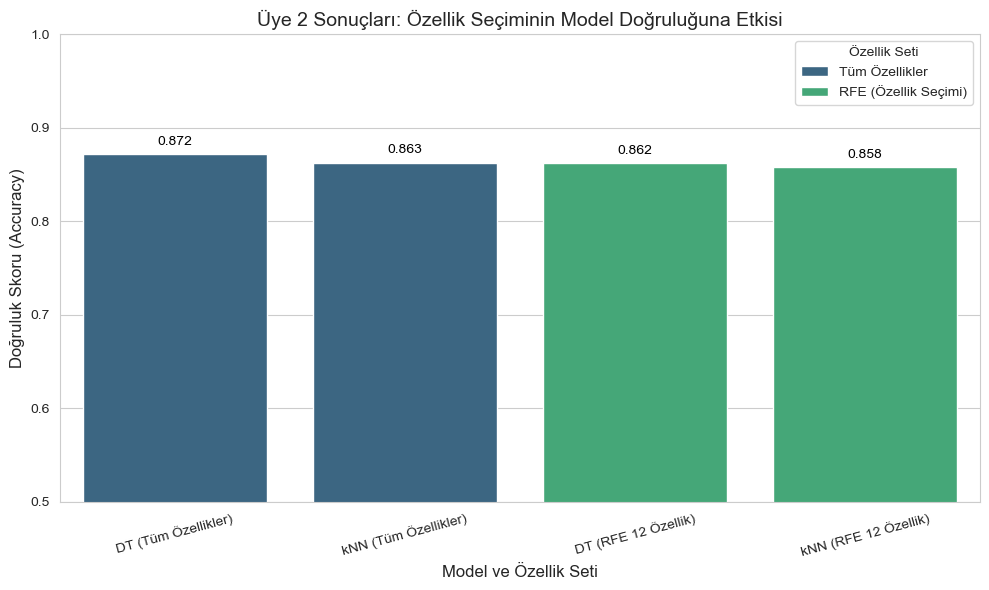


Model Karşılaştırma Grafiği oluşturuldu.


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

results = {
    'Model': [
        'DT (Tüm Özellikler)', 'kNN (Tüm Özellikler)',
        'DT (RFE 12 Özellik)', 'kNN (RFE 12 Özellik)'
    ],
    'Doğruluk': [
        acc_dt_full, acc_knn_full,
        acc_dt_rfe, acc_knn_rfe
    ],
    'Yöntem': [
        'Tüm Özellikler', 'Tüm Özellikler',
        'RFE (Özellik Seçimi)', 'RFE (Özellik Seçimi)'
    ]
}
df_results = pd.DataFrame(results)

# Görselleştirme
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_results,
    x='Model',
    y='Doğruluk',
    hue='Yöntem',
    palette='viridis' 
)

plt.ylim(0.5, 1.0) 
plt.title('Üye 2 Sonuçları: Özellik Seçiminin Model Doğruluğuna Etkisi', fontsize=14)
plt.ylabel('Doğruluk Skoru (Accuracy)', fontsize=12)
plt.xlabel('Model ve Özellik Seti', fontsize=12)

for index, row in df_results.iterrows():
    plt.text(
        index, 
        row['Doğruluk'] + 0.01, 
        f"{row['Doğruluk']:.3f}", 
        color='black', 
        ha="center"
    )

plt.legend(title='Özellik Seti')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('uye2_model_karsilastirma.png') 
plt.show()

print("\nModel Karşılaştırma Grafiği oluşturuldu.")